# 1. Setup & Dependencies

Install required packages and authenticate Kaggle API for dataset access.

In [ ]:
# --- Install dependencies ---
!pip install -q kaggle pandas numpy matplotlib opencv-python torch torchvision tqdm scikit-learn

# --- Authenticate Kaggle (requires your Kaggle API key uploaded to Colab) ---
from google.colab import files
print("Upload your kaggle.json API key file (from https://www.kaggle.com/settings/account).")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# --- Download the ODIR-5K dataset ---
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k
!unzip -q ocular-disease-recognition-odir5k.zip -d odir5k


Upload your kaggle.json API key file (from https://www.kaggle.com/settings/account).


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
 99% 1.60G/1.62G [00:13<00:00, 227MB/s]
100% 1.62G/1.62G [00:13<00:00, 133MB/s]


# 2. Imports

Load all required libraries for data processing, modeling, and visualization.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


# 3. Data Loading & Preprocessing

Load the ODIR-5K fundus image dataset and prepare labels for multi-label classification.

In [ ]:
# Path to metadata CSV (contains image names + labels)
csv_path = "odir5k/full_df.csv"  # adjust if needed
df = pd.read_csv(csv_path)
print(df.head())

# Extract image paths and one-hot labels
IMAGE_DIR = "odir5k/preprocessed_images"  # adjust if folder name differs

# All 8 disease labels
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df = df[label_cols + ['Left-Fundus', 'Right-Fundus']].dropna()

data = []
for i, row in df.iterrows():
    for side in ['Left-Fundus', 'Right-Fundus']:
        path = os.path.join(IMAGE_DIR, row[side].split('/')[-1])
        if os.path.exists(path):
            # Extract all 8 label columns
            labels = [row[col] for col in label_cols]
            data.append((path, labels))

train_df = pd.DataFrame(data, columns=['path', 'labels'])
print(f"\nLoaded {len(train_df)} images with {len(label_cols)} labels each")
train_df.head()


   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   4           53        Male  4_left.jpg  4_right.jpg   
4   5           50      Female  5_left.jpg  5_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                        macular epiretinal membrane   
4             moderate non proliferative retinopathy   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  \
0                           normal fundus  0  0  0  1  0  0  0  0   
1                           normal fundus  1  0  0  0  0  0  0  0   
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1   
3       mild nonproliferative re

,path,labels
0,odir5k/preprocessed_images/0_left.jpg,"[0, 0, 0, 1, 0, 0, 0, 0]"
1,odir5k/preprocessed_images/0_right.jpg,"[0, 0, 0, 1, 0, 0, 0, 0]"
2,odir5k/preprocessed_images/1_left.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
3,odir5k/preprocessed_images/1_right.jpg,"[1, 0, 0, 0, 0, 0, 0, 0]"
4,odir5k/preprocessed_images/2_right.jpg,"[0, 1, 0, 0, 0, 0, 0, 1]"


# 4. Dataset Definition

Custom PyTorch Dataset class for loading and processing fundus images.

In [ ]:
class FundusDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)

        # Convert label to tensor
        label = self.df.iloc[idx]['labels']
        label = np.array(label, dtype=np.float32)
        label = torch.tensor(label, dtype=torch.float32)

        return img, label



# 5. Image Transforms & Augmentation

Define preprocessing pipeline with resizing, augmentation, and normalization for PCA compatibility.

In [ ]:
from torchvision import transforms

# Resize image to 128x128 and augment w rotations, flips, color changes, zooms, shears, and greyscale for PCA
pca_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=(0.5, 1.5),
                           contrast=0.2,
                           saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=10,
                            translate=(0.05, 0.05),
                            shear=5),
    transforms.Grayscale(num_output_channels=1),

    #convert to tensor, normalize, and flatten
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.Lambda(lambda x: x.view(-1))
])

# 6. Feature Extraction

Extract flattened feature vectors from images and split into train/validation sets.

In [ ]:
#Transform dataset for PCA dimension reduction
dataset = FundusDataset(train_df, transform=pca_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)
X_list, Y_list = [], []

#Label dataset
for imgs, labels in loader:
    X_list.append(imgs.numpy())
    Y_list.append(labels.numpy())

X = np.concatenate(X_list, axis=0)
y = np.concatenate(Y_list, axis=0)

print("X_raw shape:", X.shape)
print("Y shape:", y.shape)

#Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_raw shape: (12460, 50176)
Y shape: (12460, 8)


# 8. Dimensionality Reduction (PCA)

Apply Principal Component Analysis to reduce feature dimensionality while preserving variance.

In [ ]:
#Dimension Reduction using PCA

#Set number of components - can be adjusted if accuracy is low
n_components = 200
max_components = min(n_components,
                     X_train.shape[0] - 1,
                     X_train.shape[1])

pca = PCA(n_components=max_components, whiten=True, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_val)

## 8.1 PCA Analysis Visualization

Examine explained variance and component projections.

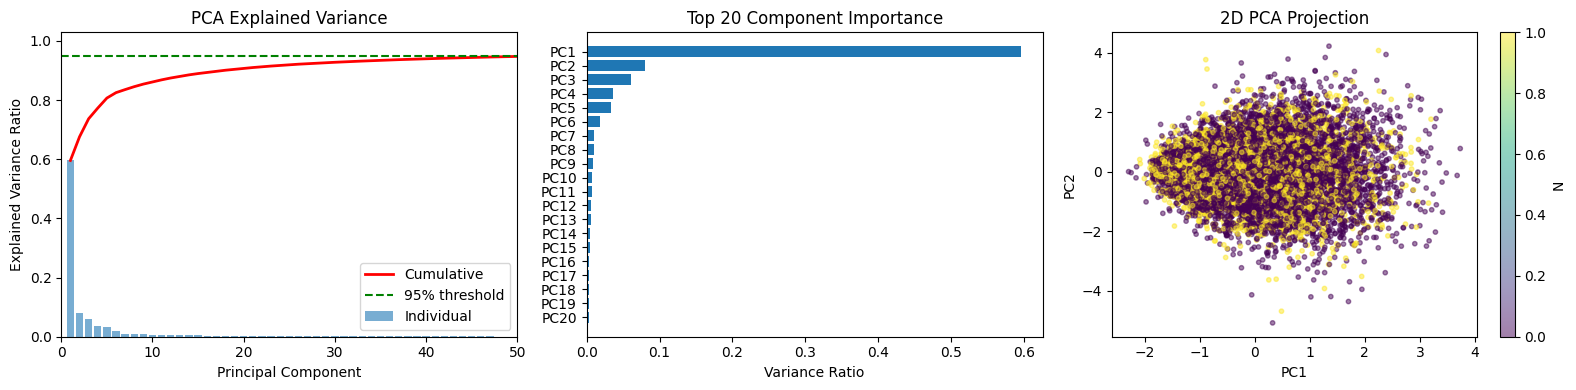


PCA Summary:
  Total components: 200
  Components for 95% variance: 54
  Variance captured: 97.99%


In [ ]:
# Visualize PCA Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Explained Variance Ratio
ax1 = axes[0]
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
ax1.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual')
ax1.plot(range(1, len(cumulative_var)+1), cumulative_var, 'r-', linewidth=2, label='Cumulative')
ax1.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('PCA Explained Variance')
ax1.legend()
ax1.set_xlim(0, min(50, len(explained_var)))

# 2. Component importance (first 20)
ax2 = axes[1]
n_show = min(20, len(explained_var))
ax2.barh(range(n_show), explained_var[:n_show][::-1])
ax2.set_yticks(range(n_show))
ax2.set_yticklabels([f'PC{i+1}' for i in range(n_show)][::-1])
ax2.set_xlabel('Variance Ratio')
ax2.set_title('Top 20 Component Importance')

# 3. 2D PCA projection
ax3 = axes[2]
y_first_label = y_train[:, 0] if len(y_train.shape) > 1 else y_train
scatter = ax3.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_first_label,
                       alpha=0.5, cmap='viridis', s=10)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('2D PCA Projection')
plt.colorbar(scatter, ax=ax3, label=label_cols[0] if 'label_cols' in dir() else 'Label')

plt.tight_layout()
plt.show()

# Summary
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\nPCA Summary:")
print(f"  Total components: {len(explained_var)}")
print(f"  Components for 95% variance: {n_95}")
print(f"  Variance captured: {cumulative_var[-1]*100:.2f}%")


# 9. Random Forest Training

Train a Random Forest classifier on PCA-reduced features with progress tracking.

In [ ]:
# Initialize RF with OOB scoring for progress tracking
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    oob_score=True,
    warm_start=True
)

# Track OOB error as trees are added
oob_errors = []
n_estimator_steps = list(range(10, 401, 10))

print("Training Random Forest with progress tracking...")
for n_est in tqdm(n_estimator_steps, desc="Adding trees"):
    rf.set_params(n_estimators=n_est)
    rf.fit(X_train_pca, y_train)
    oob_error = 1 - rf.oob_score_
    oob_errors.append(oob_error)

# Final prediction
y_pred = rf.predict(X_test_pca)

print(f"\nTraining complete!")
print(f"Final OOB Score: {rf.oob_score_:.4f}")


Training Random Forest with progress tracking...


Adding trees:   0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
Adding trees:   2%|▎         | 1/40 [00:05<03:15,  5.02s/it]/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
Adding trees: 100%|██████████| 40/40 [03:20<00:00,  5.01s/it]



Training complete!
Final OOB Score: 0.0025


# 10. Model Evaluation Metrics

Evaluate model performance using accuracy, F1-score, and per-label classification reports.

In [ ]:
# Per label metrics for deeper analysis
# Use actual number of labels from data to prevent out-of-bounds
n_labels = y_val.shape[1]
print(f"\nPer Label ({n_labels} labels)")
for j in range(n_labels):
    name = label_cols[j] if j < len(label_cols) else f'Label_{j}'
    print(f"\n----{name}:---")
    print(classification_report(y_val[:, j], y_pred[:, j], digits=3, zero_division=0))
print("\n")



Overall
Overall Accuracy (Exact Match): 0.0000
F1 Micro:     0.0000
F1 Macro:     0.0000
F1 Weighted:  0.0000



Per Label (8 labels)

----N:---
              precision    recall  f1-score   support

         0.0      0.660     0.999     0.795      1644
         1.0      0.000     0.000     0.000       848

    accuracy                          0.659      2492
   macro avg      0.330     0.500     0.397      2492
weighted avg      0.435     0.659     0.524      2492


----D:---
              precision    recall  f1-score   support

         0.0      0.670     1.000     0.802      1669
         1.0      0.000     0.000     0.000       823

    accuracy                          0.670      2492
   macro avg      0.335     0.500     0.401      2492
weighted avg      0.449     0.670     0.537      2492


----G:---
              precision    recall  f1-score   support

         0.0      0.937     1.000     0.967      2335
         1.0      0.000     0.000     0.000       157

    accuracy  